In [40]:
from pathlib import Path
import numpy as np
import mne

SUBJECT = '01'
SESSION = '01'
TASK    = 'Cannonball MF'

PROJECT_ROOT    = Path('..').resolve()
DERIVATIVES_DIR = PROJECT_ROOT / 'data' / 'derivatives' / 'mne_preproc'
sub_ses_dir     = DERIVATIVES_DIR / f'sub-{SUBJECT}' / f'ses-{SESSION}'
EPOCHS_PATH     = sub_ses_dir / f'sub-{SUBJECT}_ses-{SESSION}_task-{TASK}_epochs_feedback_clean-epo.fif'

ANTICI_TMIN = -0.5
ANTICI_TMAX =  0.0

epochs = mne.read_epochs(str(EPOCHS_PATH), preload=True, verbose=False)
epochs = epochs.pick('eeg')  # raw voltage, all EEG channels
epochs = epochs.crop(tmin=ANTICI_TMIN, tmax=ANTICI_TMAX)

print(f'Epochs loaded : {len(epochs)}')
print(f'Conditions    : {list(epochs.event_id.keys())}')
print(f'Time window   : {epochs.tmin:.3f} to {epochs.tmax:.3f} s')
print(f'n_channels    : {len(epochs.ch_names)}')
print(f'n_times       : {len(epochs.times)}')

Epochs loaded : 720
Conditions    : ['loss', 'reward']
Time window   : -0.500 to 0.000 s
n_channels    : 64
n_times       : 129


In [41]:
# 1. Create reward and loss subsets from the full epochs
reward_epochs = epochs['reward'].copy()
loss_epochs   = epochs['loss'].copy()

# 2. Clean them (remove bad trials, etc.)
reward_epochs.drop_bad()
loss_epochs.drop_bad()

# 3. Also drop any trials where expected_value is NaN (if any)
reward_epochs = reward_epochs[~reward_epochs.metadata['expected_value'].isna()]
loss_epochs   = loss_epochs[~loss_epochs.metadata['expected_value'].isna()]

# 4. Build X and y_cont directly from these cleaned objects
X = np.concatenate([reward_epochs.get_data(), loss_epochs.get_data()], axis=0)

y_cont = np.concatenate([
    reward_epochs.metadata['expected_value'].values,
    loss_epochs.metadata['expected_value'].values
])

# 5. Final sanity check
print(f'X shape: {X.shape}, y_cont shape: {y_cont.shape}')
print(f'Any NaN in X? {np.isnan(X).any()}, in y_cont? {np.isnan(y_cont).any()}')

X shape: (720, 64, 129), y_cont shape: (720,)
Any NaN in X? False, in y_cont? False


In [42]:
from mne.decoding import GeneralizingEstimator, cross_val_multiscore
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold

clf = make_pipeline(
    StandardScaler(),
    SVR(kernel='linear', C=1)
)

gen = GeneralizingEstimator(
    clf,
    scoring='r2',
    n_jobs=1
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_multiscore(gen, X, y_cont, cv=cv, n_jobs=1)
scores_mean = scores.mean(axis=0)

print(f'TGM shape : {scores_mean.shape}')
print(f'R² range : {scores_mean.min():.3f} – {scores_mean.max():.3f}')

  0%|          | Fitting GeneralizingEstimator : 0/129 [00:00<?,       ?it/s]

  0%|          | Scoring GeneralizingEstimator : 0/16641 [00:00<?,       ?it/s]

  0%|          | Fitting GeneralizingEstimator : 0/129 [00:00<?,       ?it/s]

  0%|          | Scoring GeneralizingEstimator : 0/16641 [00:00<?,       ?it/s]

  0%|          | Fitting GeneralizingEstimator : 0/129 [00:00<?,       ?it/s]

...

  0%|          | Fitting GeneralizingEstimator : 0/129 [00:00<?,       ?it/s]

  0%|          | Scoring GeneralizingEstimator : 0/16641 [00:00<?,       ?it/s]

  0%|          | Fitting GeneralizingEstimator : 0/129 [00:00<?,       ?it/s]

  0%|          | Scoring GeneralizingEstimator : 0/16641 [00:00<?,       ?it/s]

TGM shape : (129, 129)
R² range : -4.250 – -0.018


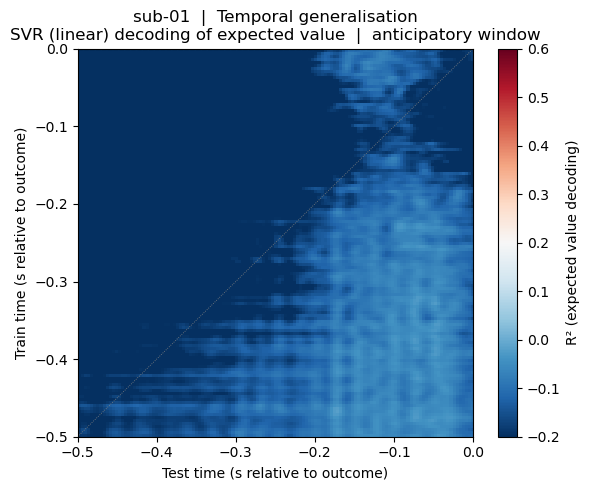

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
times = reward_epochs.times   # or epochs.times if you still have it

# For SVR, scores_mean contains R² values (could be negative)
# Adjust vmin/vmax based on your actual data range
im = ax.imshow(
    scores_mean,
    origin='lower',
    extent=[times[0], times[-1], times[0], times[-1]],
    aspect='auto',
    vmin=-0.2,        # typical lower bound for R²; change if your min is lower
    vmax=0.6,         # typical upper bound; adjust based on your max R²
    cmap='RdBu_r'
)
fig.colorbar(im, ax=ax, label='R² (expected value decoding)')

# Chance line at R² = 0 (predicting the mean)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)

# Diagonal (train == test time)
ax.plot(times, times, color='gray', linewidth=0.6, linestyle=':')

ax.set_xlabel('Test time (s relative to outcome)')
ax.set_ylabel('Train time (s relative to outcome)')
ax.set_title(
    f'sub-{SUBJECT}  |  Temporal generalisation\n'
    f'SVR (linear) decoding of expected value  |  anticipatory window'
)
plt.tight_layout()
plt.show()

In [44]:
# Save TGM results for between-subjects averaging
tgm_path = sub_ses_dir / f"sub-{SUBJECT}_ses-{SESSION}_task-{TASK}_tgm_results.npz"

np.savez(
    str(tgm_path),
    subject      = SUBJECT,
    scores_mean  = scores_mean,
    scores_all   = scores,       # (n_folds, n_train, n_test) — keep folds for group-level stats
    times        = times,
)
print(f"Saved TGM results → {tgm_path}")

Saved TGM results → /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_tgm_results.npz


In [45]:
# Get the original trial indices from the epochs objects
reward_indices = reward_epochs.selection   # or reward_epochs.times? Actually MNE Epochs has .selection
loss_indices   = loss_epochs.selection
all_indices = np.concatenate([reward_indices, loss_indices])

# Now get expected values from the full epochs object using these indices
full_metadata = epochs.metadata
expected_from_indices = full_metadata.iloc[all_indices]['expected_value'].values

# Compare with your y_cont
print(f'Are they equal? {np.allclose(y_cont, expected_from_indices)}')

Are they equal? True
